In [86]:
import pandas as pd

# Bai 1

In [87]:
df = pd.read_csv('titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
df.shape

(891, 12)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [90]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [91]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Bai 2

(np.int64(577), np.int64(314))

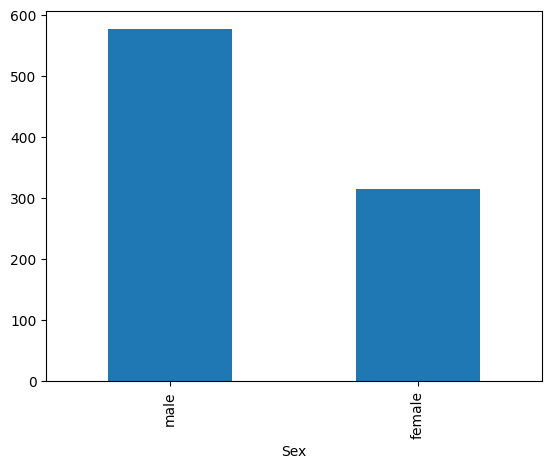

In [92]:
sex = df['Sex'].value_counts()

male = sex['male']
female = sex['female']

sex.plot.bar()
male, female

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

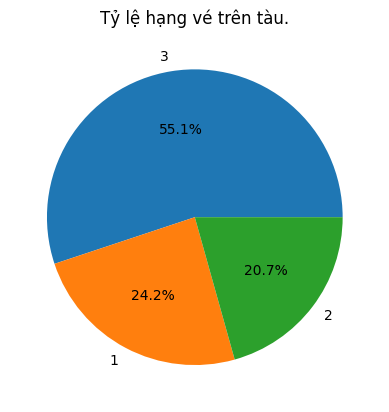

In [93]:
pclass = df['Pclass'].value_counts()
pclass.plot.pie(autopct="%1.1f%%", title='Tỷ lệ hạng vé trên tàu.')
pclass

In [94]:
Southampton_1 = ((df['Pclass']==1) & (df['Embarked']=='S')).sum()
Southampton_1


np.int64(127)

In [95]:
avg_age = df['Age'].mean()
avg_age

np.float64(29.69911764705882)

In [96]:
avg_age_survived = df[df['Survived'] == 1]
avg_age_survived['Age'].mean()

np.float64(28.343689655172415)

In [97]:
sex_survived = df[df['Survived']==1]

male_survived = (sex_survived['Sex']=='male').sum()
female_survived = (sex_survived['Sex']=='female').sum()

male_survived, female_survived

(np.int64(109), np.int64(233))

In [98]:
male_survived = male_survived/male
male_survived

np.float64(0.18890814558058924)

In [99]:
female_survived = female_survived/female
female_survived

np.float64(0.7420382165605095)

In [100]:
female_survived_age = ((df["Sex"] == "female") &
                       (df["Survived"] == 1) &
                       (df["Age"] > avg_age)).sum()

female_survived_age

np.int64(92)

# Bai 3

In [101]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [102]:
mask_p1 = ((df['Pclass']==1) & df['Age'].isna())
df.loc[mask_p1, "Age"] = avg_age

df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            147
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [103]:
median = df[df['Pclass']!=1]['Age'].median()
median

np.float64(26.0)

In [104]:

mask_p23 = (((df['Pclass']==2) | (df['Pclass']==3)) & df['Age'].isna())
df.loc[mask_p23, "Age"] = median

df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [105]:
avg_fare = df['Fare'].mean()
avg_fare

np.float64(32.204207968574636)

In [106]:
mask_fare_c = ((df['Fare']>avg_fare) & (df['Embarked'].isna()))
df.loc[mask_fare_c, 'Embarked'] = 'C'

mask_fare_s = ((df['Fare']<=avg_fare) & (df['Embarked'].isna()))
df.loc[mask_fare_s, 'Embarked'] = 'S'

df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [107]:
df = df.drop(columns='Cabin')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [108]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [109]:
df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,1


# Bai 4

In [112]:
mask_1 = (df['Pclass']==1)
avg_fare_class1 = df.loc[mask_1, 'Fare'].mean()

mask_2 = (df['Pclass']==2)
avg_fare_class2 = df.loc[mask_2, 'Fare'].mean()

mask_3 = (df['Pclass']==3)
avg_fare_class3 = df.loc[mask_3, 'Fare'].mean()

avg_fare_class1, avg_fare_class2, avg_fare_class3 

(np.float64(84.1546875),
 np.float64(20.662183152173913),
 np.float64(13.675550101832993))

In [117]:
max_fare_class1 = df.loc[mask_1, 'Fare'].max()
passenger_max_fare_class1 = df.loc[df['Fare']==max_fare_class1]
passenger_max_fare_class1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
258,259,1,1,"Ward, Miss. Anna",1,35.0,0,0,PC 17755,512.3292,C,1
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",0,36.0,0,1,PC 17755,512.3292,C,2
737,738,1,1,"Lesurer, Mr. Gustave J",0,35.0,0,0,PC 17755,512.3292,C,1


In [118]:
max_fare_class2 = df.loc[mask_2, 'Fare'].max()
passenger_max_fare_class2 = df.loc[df['Fare']==max_fare_class2]
passenger_max_fare_class2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
72,73,0,2,"Hood, Mr. Ambrose Jr",0,21.0,0,0,S.O.C. 14879,73.5,S,1
120,121,0,2,"Hickman, Mr. Stanley George",0,21.0,2,0,S.O.C. 14879,73.5,S,3
385,386,0,2,"Davies, Mr. Charles Henry",0,18.0,0,0,S.O.C. 14879,73.5,S,1
655,656,0,2,"Hickman, Mr. Leonard Mark",0,24.0,2,0,S.O.C. 14879,73.5,S,3
665,666,0,2,"Hickman, Mr. Lewis",0,32.0,2,0,S.O.C. 14879,73.5,S,3


In [119]:
max_fare_class3 = df.loc[mask_3, 'Fare'].max()
passenger_max_fare_class3 = df.loc[df['Fare']==max_fare_class3]
passenger_max_fare_class3

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
159,160,0,3,"Sage, Master. Thomas Henry",0,26.0,8,2,CA. 2343,69.55,S,11
180,181,0,3,"Sage, Miss. Constance Gladys",1,26.0,8,2,CA. 2343,69.55,S,11
201,202,0,3,"Sage, Mr. Frederick",0,26.0,8,2,CA. 2343,69.55,S,11
324,325,0,3,"Sage, Mr. George John Jr",0,26.0,8,2,CA. 2343,69.55,S,11
792,793,0,3,"Sage, Miss. Stella Anna",1,26.0,8,2,CA. 2343,69.55,S,11
846,847,0,3,"Sage, Mr. Douglas Bullen",0,26.0,8,2,CA. 2343,69.55,S,11
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",1,26.0,8,2,CA. 2343,69.55,S,11


In [121]:
mask_0_18 = ((df['Age']>=0) & (df['Age']<=18))
survived_0_18 = df.loc[mask_0_18]
survived_0_18

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,S,5
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,C,2
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",1,4.0,1,1,PP 9549,16.7000,S,3
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",1,14.0,0,0,350406,7.8542,S,1
16,17,0,3,"Rice, Master. Eugene",0,2.0,4,1,382652,29.1250,Q,6
...,...,...,...,...,...,...,...,...,...,...,...,...
852,853,0,3,"Boulos, Miss. Nourelain",1,9.0,1,1,2678,15.2458,C,3
853,854,1,1,"Lines, Miss. Mary Conover",1,16.0,0,1,PC 17592,39.4000,S,2
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",1,18.0,0,1,392091,9.3500,S,2
869,870,1,3,"Johnson, Master. Harold Theodor",0,4.0,1,1,347742,11.1333,S,3


In [122]:
mask_19_35 = ((df['Age']>=19) & (df['Age']<=35))
survived_19_35 = df.loc[mask_19_35]
survived_19_35

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,1
5,6,0,3,"Moran, Mr. James",0,26.0,0,0,330877,8.4583,Q,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,26.0,1,2,W./C. 6607,23.4500,S,4
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C,1


In [123]:
mask_36_60 = ((df['Age']>=16) & (df['Age']<=60))
survived_36_60 = df.loc[mask_36_60]
survived_36_60

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,26.0,1,2,W./C. 6607,23.4500,S,4
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C,1


In [124]:
mask_over_60 = (df['Age']>=60)
survived_over_60 = df.loc[mask_over_60]
survived_over_60

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
33,34,0,2,"Wheadon, Mr. Edward H",0,66.0,0,0,C.A. 24579,10.5000,S,1
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",0,65.0,0,1,113509,61.9792,C,2
96,97,0,1,"Goldschmidt, Mr. George B",0,71.0,0,0,PC 17754,34.6542,C,1
116,117,0,3,"Connors, Mr. Patrick",0,70.5,0,0,370369,7.7500,Q,1
170,171,0,1,"Van der hoef, Mr. Wyckoff",0,61.0,0,0,111240,33.5000,S,1
252,253,0,1,"Stead, Mr. William Thomas",0,62.0,0,0,113514,26.5500,S,1
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",1,63.0,1,0,13502,77.9583,S,2
280,281,0,3,"Duane, Mr. Frank",0,65.0,0,0,336439,7.7500,Q,1
326,327,0,3,"Nysveen, Mr. Johan Hansen",0,61.0,0,0,345364,6.2375,S,1
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",1,60.0,1,0,110813,75.2500,C,2


In [125]:
mask_high_fare = (df['Fare']>50) 
high_fare = df.loc[mask_high_fare]
high_fare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,1,0,PC 17599,71.2833,C,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,1,0,113803,53.1000,S,2
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.000000,0,0,17463,51.8625,S,1
27,28,0,1,"Fortune, Mr. Charles Alexander",0,19.000000,3,2,19950,263.0000,S,6
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",1,29.699118,1,0,PC 17569,146.5208,C,2
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",1,45.000000,1,1,36928,164.8667,S,3
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",1,26.000000,8,2,CA. 2343,69.5500,S,11
867,868,0,1,"Roebling, Mr. Washington Augustus II",0,31.000000,0,0,PC 17590,50.4958,S,1
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",1,47.000000,1,1,11751,52.5542,S,3


In [126]:
high_fare.to_csv('high_fare_passengers.csv')

In [129]:
new_df = df.groupby(['Pclass', 'Survived']).count()
new_df.to_csv('summary.csv')